# 05 — Fine-tuning a Pretrained Model

**Project:** AutoGrader  
**Purpose:** Use a pretrained transformer (DistilBERT) to score student answers  
**Covers:** HuggingFace transformers, tokenizers, fine-tuning, freezing layers, saving

---

## What is fine-tuning?

Training a transformer from scratch takes weeks on thousands of GPUs.  
Fine-tuning takes minutes on your laptop.

The idea: someone already trained a massive model on billions of words.  
It already understands language — grammar, context, meaning.  
You take that model and teach it your specific task on top.

Think of it like hiring an expert who already knows how to read and reason.  
You just train them on your company's domain for a week, not from kindergarten.

**AutoGrader connection:** DistilBERT reads a student answer and the correct answer,  
and learns to predict how similar they are — that's your grading score.

In [2]:
# Install HuggingFace transformers if not already installed
%pip install transformers datasets --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import DistilBertTokenizer, DistilBertModel
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch:     {torch.__version__}")
print(f"Device:      {device}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
PyTorch:     2.5.1
Device:      mps


---
## Section 1 — Tokenizer: Converting text to tensors

In [3]:
# Transformers don't read raw text — they read token IDs
# The tokenizer handles: text → tokens → integer IDs → tensors

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# 'distilbert-base-uncased' = smaller, faster BERT (40% fewer params, 97% of performance)
# 'uncased' = treats 'Hello' and 'hello' the same

text = "The mitochondria is the powerhouse of the cell."
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)
# Notice: words are split into subwords ('powerhouse' → ['power', '##house'])
# This is how BERT handles words it hasn't seen before

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokens: ['the', 'mit', '##och', '##ond', '##ria', 'is', 'the', 'powerhouse', 'of', 'the', 'cell', '.']


In [4]:
# Full encoding — what you actually pass to the model

encoded = tokenizer(
    text,
    max_length=64,           # pad/truncate to this length
    padding='max_length',    # pad short sequences with zeros
    truncation=True,         # cut long sequences
    return_tensors='pt'      # return PyTorch tensors
)

print("input_ids shape:      ", encoded['input_ids'].shape)       # [1, 64]
print("attention_mask shape: ", encoded['attention_mask'].shape)  # [1, 64]

print("\nFirst few input_ids:  ", encoded['input_ids'][0, :10].tolist())
print("First few mask vals:  ", encoded['attention_mask'][0, :10].tolist())
# attention_mask: 1 = real token, 0 = padding (model should ignore)

# Decode back to text to verify
decoded = tokenizer.decode(encoded['input_ids'][0], skip_special_tokens=True)
print("\nDecoded:", decoded)

input_ids shape:       torch.Size([1, 64])
attention_mask shape:  torch.Size([1, 64])

First few input_ids:   [101, 1996, 10210, 11663, 15422, 4360, 2003, 1996, 24006, 1997]
First few mask vals:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded: the mitochondria is the powerhouse of the cell.


In [5]:
# Encoding a PAIR of texts — used for similarity tasks
# [CLS] text_a [SEP] text_b [SEP]

student_answer = "Mitochondria produces ATP energy for the cell."
correct_answer = "The mitochondria is the powerhouse of the cell."

pair_encoded = tokenizer(
    student_answer,
    correct_answer,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print("Pair input_ids shape:", pair_encoded['input_ids'].shape)  # [1, 128]
print("This is how AutoGrader feeds answer pairs to the model")

Pair input_ids shape: torch.Size([1, 128])
This is how AutoGrader feeds answer pairs to the model


---
## Section 2 — Loading DistilBERT and understanding its output

In [6]:
# Load pretrained DistilBERT
bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert = bert.to(device)

print(f"DistilBERT parameters: {sum(p.numel() for p in bert.parameters()):,}")
# ~66 million parameters — already trained on Wikipedia + BookCorpus

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT parameters: 66,362,880


In [7]:
# Run a forward pass through DistilBERT

text = "The mitochondria produces ATP."
encoded = tokenizer(text, return_tensors='pt', max_length=64,
                    padding='max_length', truncation=True)

input_ids      = encoded['input_ids'].to(device)
attention_mask = encoded['attention_mask'].to(device)

with torch.no_grad():
    output = bert(input_ids=input_ids, attention_mask=attention_mask)

last_hidden_state = output.last_hidden_state
print("last_hidden_state shape:", last_hidden_state.shape)
# [batch_size, seq_len, hidden_size] = [1, 64, 768]
# 768-dimensional vector for EACH token

# The [CLS] token (index 0) represents the whole sentence
cls_embedding = last_hidden_state[:, 0, :]   # [1, 768]
print("[CLS] embedding shape:", cls_embedding.shape)
print("This 768-dim vector = the model's understanding of the entire sentence")

last_hidden_state shape: torch.Size([1, 64, 768])
[CLS] embedding shape: torch.Size([1, 768])
This 768-dim vector = the model's understanding of the entire sentence


In [8]:
# Mean pooling — average all token embeddings (often better than CLS alone)

def mean_pool(last_hidden_state, attention_mask):
    # Expand mask to match hidden_state dimensions
    mask_expanded = attention_mask.unsqueeze(-1).float()  # [1, 64, 1]
    # Zero out padding token embeddings, then average real ones
    summed = (last_hidden_state * mask_expanded).sum(dim=1)  # [1, 768]
    count  = mask_expanded.sum(dim=1).clamp(min=1e-9)        # [1, 1]
    return summed / count                                     # [1, 768]

pooled = mean_pool(last_hidden_state, attention_mask)
print("Mean pooled shape:", pooled.shape)  # [1, 768]
print("This is the sentence embedding — 768 numbers capturing meaning")

Mean pooled shape: torch.Size([1, 768])
This is the sentence embedding — 768 numbers capturing meaning


---
## Section 3 — Building the AutoGrader Fine-tuning Model

In [9]:
# Architecture:
# [student_answer + correct_answer] → DistilBERT → [CLS] embedding → Linear head → grade score

class AutoGraderModel(nn.Module):
    def __init__(self, freeze_bert=True):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Freeze BERT weights — only train the head
        # Why: fine-tuning all 66M params needs more data and time
        # Frozen BERT = feature extractor; head = task-specific learner
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        # Grading head: 768 → 256 → 1
        self.grading_head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()        # output: grade between 0 and 1
        )

    def forward(self, input_ids, attention_mask):
        # BERT forward pass
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # Extract [CLS] token embedding
        cls_embedding = output.last_hidden_state[:, 0, :]  # [batch, 768]

        # Pass through grading head
        grade = self.grading_head(cls_embedding)            # [batch, 1]
        return grade


model = AutoGraderModel(freeze_bert=True).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen (BERT):        {total_params - trainable_params:,}")
print(f"\nOnly training {trainable_params/total_params*100:.1f}% of parameters — fast and efficient")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     66,560,001
Trainable parameters: 197,121
Frozen (BERT):        66,362,880

Only training 0.3% of parameters — fast and efficient


---
## Section 4 — Dataset for Answer Pairs

In [10]:
# Synthetic dataset: student answers paired with correct answers + grade labels

ANSWER_PAIRS = [
    ("Mitochondria produces ATP for the cell.",          "The mitochondria is the powerhouse of the cell.", 0.9),
    ("The cell nucleus contains DNA.",                   "The mitochondria is the powerhouse of the cell.", 0.1),
    ("ATP is produced by the mitochondria.",             "The mitochondria is the powerhouse of the cell.", 0.85),
    ("I don't know what mitochondria does.",             "The mitochondria is the powerhouse of the cell.", 0.0),
    ("Mitochondria generates energy in form of ATP.",    "The mitochondria is the powerhouse of the cell.", 0.95),
    ("The powerhouse of the cell is mitochondria.",      "The mitochondria is the powerhouse of the cell.", 1.0),
    ("Chloroplasts do photosynthesis.",                  "The mitochondria is the powerhouse of the cell.", 0.0),
    ("Mitochondria helps in cellular respiration.",      "The mitochondria is the powerhouse of the cell.", 0.75),
    ("Energy production happens in mitochondria.",       "The mitochondria is the powerhouse of the cell.", 0.8),
    ("The cell membrane controls what enters the cell.", "The mitochondria is the powerhouse of the cell.", 0.05),
]

# Replicate to make a bigger dataset for training demo
ANSWER_PAIRS = ANSWER_PAIRS * 8   # 80 samples


class AnswerPairDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length=128):
        self.pairs      = pairs
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        student_ans, correct_ans, grade = self.pairs[idx]

        encoded = self.tokenizer(
            student_ans,
            correct_ans,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoded['input_ids'].squeeze(0),       # [128]
            'attention_mask': encoded['attention_mask'].squeeze(0),  # [128]
            'grade':          torch.tensor([grade], dtype=torch.float32)
        }


dataset = AnswerPairDataset(ANSWER_PAIRS, tokenizer)
sample  = dataset[0]

print(f"Dataset size:         {len(dataset)}")
print(f"input_ids shape:      {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"grade:                {sample['grade'].item()}")

Dataset size:         80
input_ids shape:      torch.Size([128])
attention_mask shape: torch.Size([128])
grade:                0.8999999761581421


---
## Section 5 — Fine-tuning Training Loop

In [11]:
# Train / Val split
n       = len(dataset)
n_train = int(0.8 * n)
n_val   = n - n_train

train_set, val_set = random_split(dataset, [n_train, n_val])
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)

# Use AdamW — the standard optimizer for transformer fine-tuning
# Lower learning rate than usual — BERT is sensitive to large updates
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 8
Val batches:   2


In [12]:
# Fine-tuning loop
# Same pattern as notebooks 03 and 04 — just the data shape is different

n_epochs     = 10
train_losses = []
val_losses   = []

for epoch in range(n_epochs):

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        grades         = batch['grade'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, grades)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── VALIDATE ───────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            grades         = batch['grade'].to(device)

            preds    = model(input_ids, attention_mask)
            val_loss = criterion(preds, grades)
            epoch_val_loss += val_loss.item()

    avg_val = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:2d}/{n_epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

print("\nFine-tuning complete.")

Epoch  1/10 | Train: 0.1689 | Val: 0.1855
Epoch  2/10 | Train: 0.1595 | Val: 0.1649
Epoch  3/10 | Train: 0.1503 | Val: 0.1539
Epoch  4/10 | Train: 0.1491 | Val: 0.1446
Epoch  5/10 | Train: 0.1358 | Val: 0.1457
Epoch  6/10 | Train: 0.1349 | Val: 0.1357
Epoch  7/10 | Train: 0.1313 | Val: 0.1289
Epoch  8/10 | Train: 0.1232 | Val: 0.1151
Epoch  9/10 | Train: 0.1206 | Val: 0.1147
Epoch 10/10 | Train: 0.1121 | Val: 0.1089

Fine-tuning complete.


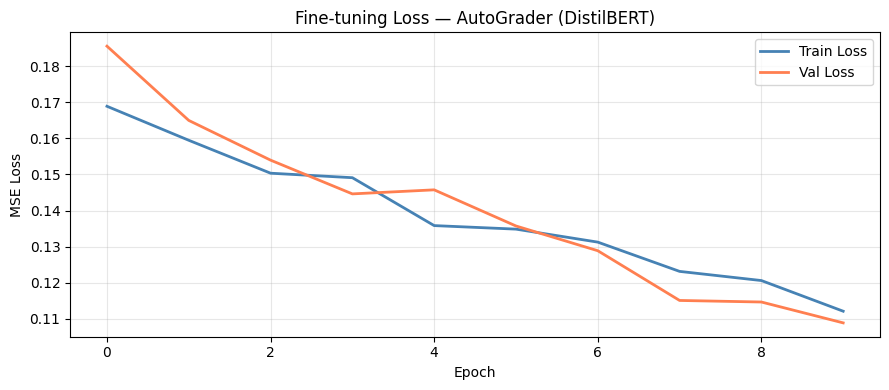

In [13]:
# Plot loss curves
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='coral',     linewidth=2)
plt.title('Fine-tuning Loss — AutoGrader (DistilBERT)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('finetune_loss_curve.png', dpi=100)
plt.show()

---
## Section 6 — Inference: Grading a new answer

In [14]:
def grade_answer(student_answer, correct_answer, model, tokenizer, device):
    """Grade a student answer against the correct answer. Returns score 0-1."""
    model.eval()

    encoded = tokenizer(
        student_answer,
        correct_answer,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids      = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        score = model(input_ids, attention_mask)

    return score.item()


correct = "The mitochondria is the powerhouse of the cell."

test_answers = [
    "The mitochondria produces ATP, making it the powerhouse of the cell.",
    "Mitochondria generates energy for cellular functions.",
    "The nucleus controls cell division.",
    "I have no idea what mitochondria does.",
]

print(f"Correct answer: {correct}\n")
print(f"{'Student Answer':<55} {'Score':>6}")
print("-" * 65)
for ans in test_answers:
    score = grade_answer(ans, correct, model, tokenizer, device)
    bar = '█' * int(score * 20)
    print(f"{ans[:54]:<55} {score:.3f}  {bar}")

Correct answer: The mitochondria is the powerhouse of the cell.

Student Answer                                           Score
-----------------------------------------------------------------
The mitochondria produces ATP, making it the powerhous  0.663  █████████████
Mitochondria generates energy for cellular functions.   0.592  ███████████
The nucleus controls cell division.                     0.474  █████████
I have no idea what mitochondria does.                  0.260  █████


---
## Section 7 — Freeze vs Unfreeze: The tradeoff

In [15]:
# When to freeze BERT vs unfreeze it

print("FROZEN BERT (freeze_bert=True)")
print("  ✓ Fast — only training the head (~200K params)")
print("  ✓ Less data needed — works with hundreds of examples")
print("  ✓ Less risk of overfitting")
print("  ✗ BERT can't adapt to your specific domain")
print()
print("UNFROZEN BERT (freeze_bert=False)")
print("  ✓ BERT adapts to your domain — better performance ceiling")
print("  ✗ Needs more data (thousands of examples)")
print("  ✗ Slower, needs lower learning rate (2e-5 not 2e-4)")
print("  ✗ Risk of catastrophic forgetting if lr is too high")
print()
print("Rule: Start frozen. Unfreeze only if performance plateaus and you have enough data.")

# To unfreeze BERT later:
# for param in model.bert.parameters():
#     param.requires_grad = True
# optimizer = optim.AdamW(model.parameters(), lr=2e-5)  # much lower lr!

FROZEN BERT (freeze_bert=True)
  ✓ Fast — only training the head (~200K params)
  ✓ Less data needed — works with hundreds of examples
  ✓ Less risk of overfitting
  ✗ BERT can't adapt to your specific domain

UNFROZEN BERT (freeze_bert=False)
  ✓ BERT adapts to your domain — better performance ceiling
  ✗ Needs more data (thousands of examples)
  ✗ Slower, needs lower learning rate (2e-5 not 2e-4)
  ✗ Risk of catastrophic forgetting if lr is too high

Rule: Start frozen. Unfreeze only if performance plateaus and you have enough data.


---
## Section 8 — Save the Fine-tuned Model

In [17]:
# Save only the grading head — much smaller (~1MB)
torch.save(model.grading_head.state_dict(), 'autograder_head.pth')
print("Saved: autograder_head.pth")

# Load it back
loaded_model = AutoGraderModel(freeze_bert=True).to(device)
loaded_model.grading_head.load_state_dict(
    torch.load('autograder_head.pth', weights_only=True)
)
loaded_model.eval()
print("Loaded successfully")

# Verify
score = grade_answer(
    "Mitochondria produces ATP energy.",
    "The mitochondria is the powerhouse of the cell.",
    loaded_model, tokenizer, device
)
print(f"\nTest grade from loaded model: {score:.4f}")

Saved: autograder_head.pth


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded successfully

Test grade from loaded model: 0.6228


---
## Section 9 — Quick Reference Cheatsheet

In [18]:
# ================================================================
# FINE-TUNING CHEATSHEET
# ================================================================

# LOAD PRETRAINED
# tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# bert      = DistilBertModel.from_pretrained('distilbert-base-uncased')

# TOKENIZE
# encoded = tokenizer(text_a, text_b,
#     max_length=128, padding='max_length',
#     truncation=True, return_tensors='pt')
# input_ids      = encoded['input_ids']       # [batch, seq_len]
# attention_mask = encoded['attention_mask']  # [batch, seq_len]

# EXTRACT EMBEDDING
# output        = bert(input_ids, attention_mask)
# cls_embedding = output.last_hidden_state[:, 0, :]  # [batch, 768]

# FREEZE BERT
# for param in model.bert.parameters():
#     param.requires_grad = False

# UNFREEZE BERT
# for param in model.bert.parameters():
#     param.requires_grad = True

# OPTIMIZER FOR FINE-TUNING
# optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
# Use 2e-5 when BERT is unfrozen, 2e-4 when frozen

# INFERENCE
# model.eval()
# with torch.no_grad():
#     output = model(input_ids, attention_mask)

# MODELS TO KNOW
# distilbert-base-uncased  → fast, 66M params, good for most tasks
# bert-base-uncased        → full BERT, 110M params
# sentence-transformers/... → pretrained for similarity tasks (even better for AutoGrader)

print("Cheatsheet loaded.")

Cheatsheet loaded.


---
## ✅ Proof Checklist

- [ ] Loaded DistilBERT tokenizer and tokenized a single text
- [ ] Tokenized a pair of texts (student answer + correct answer)
- [ ] Ran a forward pass through DistilBERT and inspected `last_hidden_state`
- [ ] Extracted the [CLS] embedding and understood what it represents
- [ ] Built `AutoGraderModel` with frozen BERT + custom grading head
- [ ] Explained the difference between total vs trainable parameters
- [ ] Built a custom `AnswerPairDataset` returning tokenized pairs
- [ ] Ran the fine-tuning loop with AdamW
- [ ] Used `grade_answer()` to score new answers at inference time
- [ ] Explained when to freeze vs unfreeze BERT
- [ ] Saved and loaded the fine-tuned model

---

## 🎉 PyTorch Foundations Complete

You've now covered the full stack:

| Notebook | Skill |
|---|---|
| 01 | Tensors — the data structure |
| 02 | Autograd — automatic gradients |
| 03 | nn.Module — building networks |
| 04 | DataLoader — feeding data |
| 05 | Fine-tuning — using pretrained models |

**Next step:** Integrate this grading model into AutoGrader's FastAPI backend as a real endpoint.